In [8]:
# for DDPG for continuous action space

from tqdm import tqdm
import collections
import numpy as np
import random  # for random sample from the replay buffer
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [9]:
class PolicyNet(nn.Module):
    # state-->hidden (fc1)+RelU -->hidden (fc2)+tanh -->bounded
    def __init__(self, state_dim, hidden_dim, action_dim, action_max):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)
        self.action_max = action_max  # the bound of action value

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        return torch.tanh(self.fc2(x)) * self.action_max

In [3]:
class QNet(torch.nn.Module):
    # (s,a)-->fc1+ReLU1 (hidden_dim) -->fc2+ReLU2 (hidden_dim)
    #      -->fc_out(1)
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.ReLU2 = nn.LeakyReLU(inplace = True)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1)
        x = self.ReLU1(self.fc1(cat))
        x = self.ReLU2(self.fc2(x))
        return self.fc_out(x)

In [10]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity) 

    def add(self, state, action, reward, next_state, done): 
        self.buffer.append((state, action, reward, next_state, done)) 

    def sample(self, batch_size): 
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state), done 

    def size(self): 
        return len(self.buffer)

# different
def take_action(actor, state, sigma, action_dim, action_max, device):
    state = torch.tensor([state], dtype=torch.float).to(device)
    action = actor(state).item()
    # adding noise for exploration
    action = action + sigma * np.random.randn(action_dim)
    action = np.clip(action,-action_max, action_max)
    return action

# same
def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

def targetNet_update(net, target_net, rho):
    for param_target, param in zip(target_net.parameters(), net.parameters()):
        param_target.data.copy_(param_target.data * rho + param.data * (1.0 - rho))

In [37]:
return_lists = []

In [64]:
actor_lr = 2e-4
critic_lr = 2e-3
num_episodes = 200
hidden_dim = 64
gamma = 0.98
rho = 0.996    # tau = 0.004
buffer_size = 10000
minimal_size = 1000
batch_size = 64
sigma = 0.01  # Gaussian standard deviation
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'Pendulum-v0'
env = gym.make(env_name)
seed = 2
random.seed(seed)
np.random.seed(seed)
env.seed(seed)
torch.manual_seed(seed)
replay_buffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_max = env.action_space.high[0]
print(state_dim, action_dim, action_max)

3 1 2.0


In [65]:
actor = PolicyNet(state_dim, hidden_dim, action_dim, action_max).to(device)
# PolicyNet(state_dim, hidden_dim, action_dim, action_max)

critic = QNet(state_dim, hidden_dim, action_dim).to(device)
# QNet(state_dim, hidden_dim, action_dim)

target_actor = PolicyNet(state_dim, hidden_dim, action_dim, action_max).to(device)
target_critic = QNet(state_dim, hidden_dim, action_dim).to(device)

# initialize target critic net and target actor net
target_critic.load_state_dict(critic.state_dict())
target_actor.load_state_dict(actor.state_dict())

# define optimizers
actor_optimizer = torch.optim.Adam(actor.parameters(), lr=actor_lr)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=critic_lr)

# start off-policy training
return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Group %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                # take_action(actor, state, sigma, action_dim, action_max, device)
                action = take_action(actor, state, sigma, action_dim, action_max, device)
                next_state, reward, done, _ = env.step(action)
                replay_buffer.add(state, action, reward, next_state, done)
                state = next_state
                episode_return += reward
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    trans_dict = {'states': b_s, 'actions': b_a, 'next_states': b_ns, 'rewards': b_r, 'dones': b_d}
                    #agent.update(transition_dict)
                    states = torch.tensor(trans_dict['states'], dtype=torch.float).to(device)
                    actions = torch.tensor(trans_dict['actions'], dtype=torch.float).view(-1, 1).to(device)
                    #actions = torch.clamp(actions, -action_max, action_max)
                    rewards = torch.tensor(trans_dict['rewards'], dtype=torch.float).view(-1, 1).to(device)
                    next_states = torch.tensor(trans_dict['next_states'], dtype=torch.float).to(device)
                    dones = torch.tensor(trans_dict['dones'], dtype=torch.float).view(-1, 1).to(device)
                    
                    # compute target
                    next_q_values = target_critic(next_states, target_actor(next_states))
                    q_targets = rewards + gamma * next_q_values * (1 - dones)
                    
                    critic_loss = torch.mean(F.mse_loss(critic(states, actions), q_targets))
                    critic_optimizer.zero_grad()
                    critic_loss.backward()
                    critic_optimizer.step()

                    actor_loss = -torch.mean(critic(states, actor(states)))
                    actor_optimizer.zero_grad()
                    actor_loss.backward()
                    actor_optimizer.step()
                    
                    # targetNet_update(net, target_net, rho)
                    targetNet_update(actor, target_actor,rho)  
                    targetNet_update(critic, target_critic,rho) 
                    
            return_list.append(episode_return)
            
            ############################
           
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

return_lists.append(return_list)  
# save multiple runs with different env.seed()
# make sure change the seed before running this cell each time

Group 9: 100%|███████████████████████████████████████████| 20/20 [00:31<00:00,  1.57s/it, episode=200, return=-160.611]


In [66]:
len(return_lists)

3

In [67]:
#del return_lists[0]

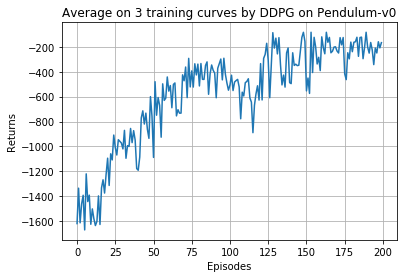

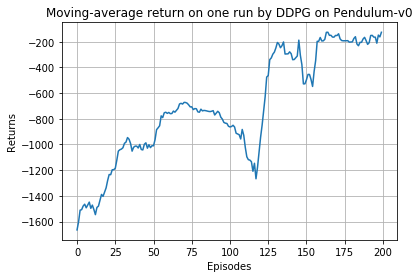

In [68]:
average_list = np.mean(return_lists, axis=0)
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, average_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Average on {} training curves by DDPG on {}'.format(len(return_lists),env_name))
plt.grid()
plt.show()

mv_return = moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Moving-average return on one run by DDPG on {}'.format(env_name))
plt.grid()
plt.show()


In [69]:

total_reward = 0.0
with torch.no_grad():
    for j in range (10):
        total_reward = 0.0  # for 10 consecutive episodes
        for i in range (10): 
            done = False
            observation = env.reset()
            t=0
            while not done:
                t += 1
                if i == 0:
                    env.render()
                #action = take_action(actor,observation)
                action = take_action(actor, observation, 0.0, action_dim, action_max, device)
                observation_new, reward, done, info = env.step(action)
                observation = observation_new
                total_reward += reward
        #print("group",j, "reward", total_reward)
        print("Group", j, "average reward (per timestep) =", total_reward/(10.*200))
env.close()           



Group 0 average reward (per timestep) = -1.1670049209778974
Group 1 average reward (per timestep) = -0.7482164551127445
Group 2 average reward (per timestep) = -1.0038127083357733
Group 3 average reward (per timestep) = -0.6766132136846437
Group 4 average reward (per timestep) = -0.8228303832665556
Group 5 average reward (per timestep) = -0.938565078823866
Group 6 average reward (per timestep) = -0.6696835295239975
Group 7 average reward (per timestep) = -0.991029285415316
Group 8 average reward (per timestep) = -0.7016028402946265
Group 9 average reward (per timestep) = -0.5546691499111333
